In [26]:
import spacy
from collections import defaultdict, Counter
import matplotlib.pyplot as plt


In [27]:
# Load spaCy model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Model not found. Please run: python -m spacy download en_core_web_sm")

In [28]:
# Sample input text
text = """
Apple Inc. is an American multinational technology company headquartered in Cupertino, California. 
Steve Jobs was a co-founder of Apple Inc. and played a key role in the development of the Macintosh computer.
The Eiffel Tower is a wrought-iron lattice tower located on the Champ de Mars in Paris, France.
"""

# Process text
doc = nlp(text)

In [29]:
# Extract and display named entities
def extract_entities(doc):
    print("\nNamed Entities:")
    for ent in doc.ents:
        print(f"{ent.text} ({ent.label_})")

In [30]:
# Count entities and visualize distribution
def count_entities(doc):
    entity_counts = defaultdict(int)
    for ent in doc.ents:
        entity_counts[ent.label_] += 1

    # Visualization
    plt.figure(figsize=(8, 5))
    plt.bar(entity_counts.keys(), entity_counts.values(), color='skyblue')
    plt.title("Entity Type Distribution")
    plt.xlabel("Entity Type")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    return entity_counts

In [31]:
# Enhanced frequency analysis
def analyze_entity_frequencies(doc):
    freq = Counter((ent.text, ent.label_) for ent in doc.ents)
    sorted_freq = freq.most_common()
    print("\nEntity Frequencies (Sorted):")
    for (text, label), count in sorted_freq:
        print(f"{text} ({label}): {count}")
    return sorted_freq

In [32]:
# Multi-word entity filtering
def compare_multiword_entities(doc):
    all_ents = Counter(ent.label_ for ent in doc.ents)
    multiword_ents = Counter(ent.label_ for ent in doc.ents if len(ent.text.split()) > 1)

    labels = list(set(all_ents.keys()).union(multiword_ents.keys()))
    all_counts = [all_ents.get(label, 0) for label in labels]
    multi_counts = [multiword_ents.get(label, 0) for label in labels]

    x = range(len(labels))
    plt.figure(figsize=(10, 6))
    plt.bar(x, all_counts, width=0.4, label="All Entities", align='center')
    plt.bar([i + 0.4 for i in x], multi_counts, width=0.4, label="Multi-word Only", align='center')
    plt.xticks([i + 0.2 for i in x], labels)
    plt.xlabel("Entity Type")
    plt.ylabel("Count")
    plt.title("Entity Distribution Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


Named Entities:
Apple Inc. (ORG)
American (NORP)
Cupertino (GPE)
California (GPE)
Steve Jobs (PERSON)
Apple Inc. (ORG)
Macintosh (ORG)
The Eiffel Tower (LOC)
the Champ de Mars (FAC)
Paris (GPE)
France (GPE)


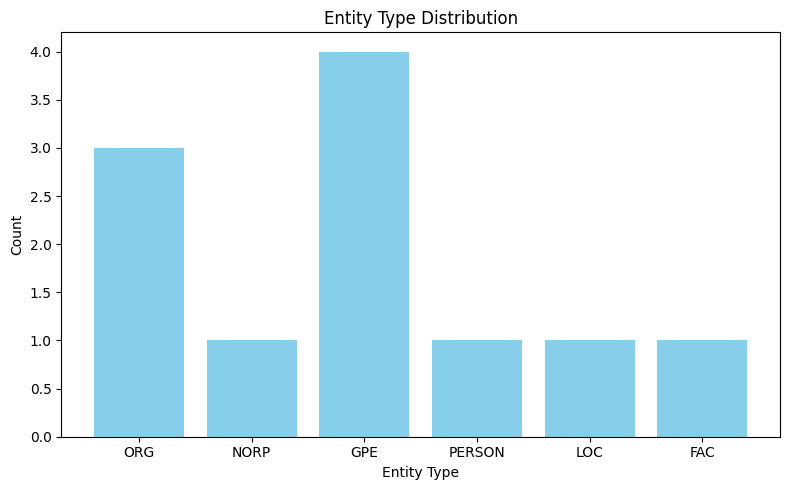


Entity Frequencies (Sorted):
Apple Inc. (ORG): 2
American (NORP): 1
Cupertino (GPE): 1
California (GPE): 1
Steve Jobs (PERSON): 1
Macintosh (ORG): 1
The Eiffel Tower (LOC): 1
the Champ de Mars (FAC): 1
Paris (GPE): 1
France (GPE): 1


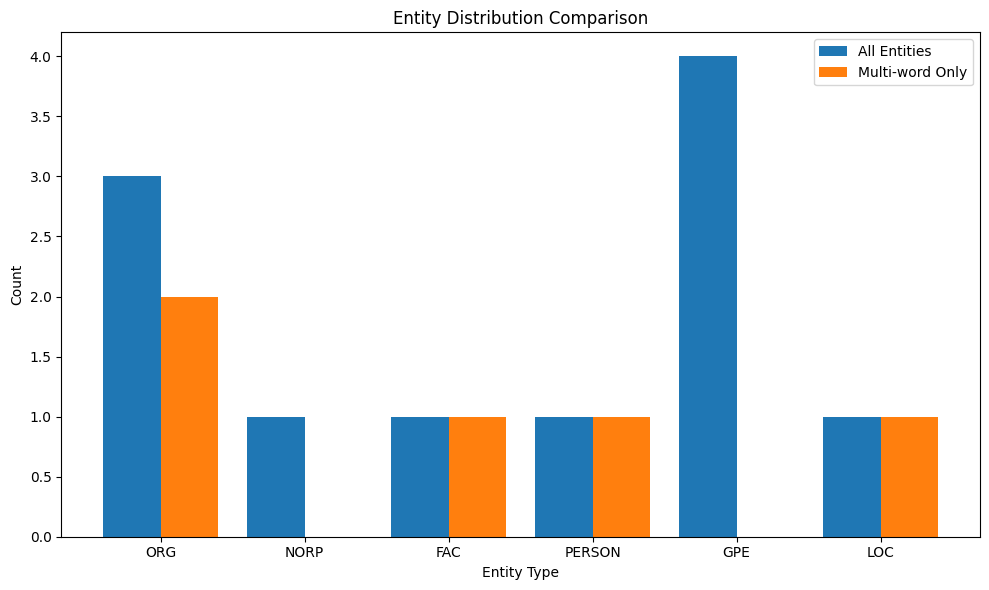


Summary Statistics:
Total entities: 11
Multi-word entities: 5
Entity counts by type:
ORG: 3
NORP: 1
GPE: 4
PERSON: 1
LOC: 1
FAC: 1


In [33]:
# Summary statistics
def summary_statistics(doc):
    total_entities = len(doc.ents)
    multiword_entities = [ent for ent in doc.ents if len(ent.text.split()) > 1]
    by_type = Counter(ent.label_ for ent in doc.ents)

    print("\nSummary Statistics:")
    print(f"Total entities: {total_entities}")
    print(f"Multi-word entities: {len(multiword_entities)}")
    print("Entity counts by type:")
    for label, count in by_type.items():
        print(f"{label}: {count}")

# Execute all tasks
extract_entities(doc)
entity_counts = count_entities(doc)
sorted_freq = analyze_entity_frequencies(doc)
compare_multiword_entities(doc)
summary_statistics(doc)

Questions:

1. What is Named Entity Recognition (NER) and why is it useful?

NER is the process of identifying and classifying key information in text, such as:

PERSON (e.g., Steve Jobs)

ORG (e.g., Apple Inc.)

GPE (e.g., France)

Applications:

Resume parsing

Chatbots and virtual assistants

Information retrieval and summarization

Customer feedback analysis

2. Entity Counting System Implementation
Used defaultdict(int) and Counter for:

Counting entity types (e.g., PERSON, ORG)

Counting specific entities with labels using tuple keys like (ent.text, ent.label_)

These structures simplify frequency tracking and allow sorted outputs easily.

3. Visualization Approach
Used matplotlib.pyplot.bar to display:

Entity type distributions

Comparison between all vs multi-word entities

Insights:

Shows which types (like PERSON or ORG) dominate

Highlights how multi-word entities contribute to entity types

Improvements:

Add counts on top of bars

Use horizontal bars for longer labels

Add interactivity (e.g., via Plotly)

4. Multi-word Entity Filtering
Criteria: len(ent.text.split()) > 1

Effect: Filters entities like “Apple Inc.” and “Eiffel Tower”

Implication: Helps assess NER accuracy in detecting proper noun phrases

5. Evaluation of the NER System
Successfully identified:

Apple Inc. (ORG)

Steve Jobs (PERSON)

Paris (GPE)

Misclassifications:

Occasionally spaCy misses proper noun spans or mislabels (rare in small texts)

Improvement:

Use larger models (like en_core_web_trf)

Fine-tune on custom domain-specific corpora

